# Домашнее задание 5 

## Часть 1 — Анализ FastQC (до тримминга)

### 1.1 Выбор данных

С помощью SRA Explorer из проекта PRJEB84057 были выбраны 4 файла (Illumina HiSeq 4000, RNA-seq, объём < 1000 Mb каждый): ERR14230586,  ERR14230599,  ERR14230602, ERR14230607

### 1.2 Организация рабочего пространства

Была создана следующая структура директорий:

### 1.3 Скачивание данных

Скрипт `download_data.sh`:

### 1.4 SLURM-скрипт: FastQC + MultiQC (до тримминга)

Файл `run_fastqc_multiqc.slurm`:

### 1.5 Результаты FastQC до тримминга

Сводная таблица статусов по модулям FastQC (Pass / Warn / Fail):

| Модуль | ERR14230586 | ERR14230599 | ERR14230602 | ERR14230607 |
|---|---|---|---|---|
| Basic statistics | ✅ Pass | ✅ Pass | ✅ Pass | ✅ Pass |
| Per-base sequence quality | ✅ Pass | ✅ Pass | ✅ Pass | ✅ Pass |
| Per-tile sequence quality | ✅ Pass | ✅ Pass | ✅ Pass | ⚠️ Warn |
| Per-sequence quality scores | ✅ Pass | ✅ Pass | ✅ Pass | ✅ Pass |
| **Per-base sequence content** | ⚠️ Warn | ❌ Fail | ❌ Fail | ❌ Fail |
| **Per-sequence GC content** | ⚠️ Warn | ❌ Fail | ⚠️ Warn | ❌ Fail |
| Per-base N content | ✅ Pass | ✅ Pass | ✅ Pass | ✅ Pass |
| Sequence length distribution | ⚠️ Warn | ⚠️ Warn | ⚠️ Warn | ⚠️ Warn |
| **Sequence duplication levels** | ✅ Pass | ✅ Pass | ✅ Pass | ❌ Fail |
| **Overrepresented sequences** | ⚠️ Warn | ⚠️ Warn | ⚠️ Warn | ❌ Fail |
| Adapter content | ✅ Pass | ✅ Pass | ✅ Pass | ✅ Pass |

Общая статистика образцов:

| Образец | % Dups | % GC | Ср. длина (bp) | M Seqs |
|---|---|---|---|---|
| ERR14230586 | 22.9% | 46% | 45 | 1.8 |
| ERR14230599 | 18.8% | 47% | 47 | 2.0 |
| ERR14230602 | 15.3% | 46% | 46 | 1.8 |
| ERR14230607 | 64.1% | 49% | 41 | 1.1 |

### 1.6 Проблемные аспекты (из отчётов до тримминга)

**1. Per-base sequence content — Fail у 3 образцов**

Неравномерное нуклеотидное содержание в первых ~10–13 позициях рида. Это артефакт random hexamer priming для RNA-seq библиотек: случайные гексамерные праймеры неравномерно гибридизуются с матрицей, создавая систематическое смещение состава нуклеотидов в начале ридов. Это биологический артефакт, не технический, таким образрм тримминг его не устраняет.

**2. Per-sequence GC content — Fail у 2 образцов, Warn у 2**

Отклонение GC-распределения от теоретически ожидаемого. Для RNA-seq это может отражать реальное биологическое разнообразие транскриптома или неравномерность амплификации. Может также указывать на присутствие рибосомальных РНК.

**3. Overrepresented sequences — Fail у ERR14230607, Warn у остальных**

Наличие последовательностей, встречающихся значительно чаще ожидаемого. Вероятнее всего — рРНК или другие высокоабундантные транскрипты.

**4. ERR14230607 — образец с проблемами качества**

- Уровень дупликатов 64.1% (в 3–4 раза выше остальных)
- Per-tile sequence quality: Warn — возможен локальный дефект flowcell
- Наименьшее количество ридов: 1.1M

**5. Адаптеры — Pass у всех образцов**

Адаптерные последовательности в данных не обнаружены. Возможно, данные были предобработаны до загрузки в ENA, либо риды достаточно короткие и не достигают адаптерных участков.

---
## Часть 2 — Тримминг с fastp

### 2.1 Ответы на вопросы по отчётам MultiQC

**Есть ли адаптеры?**  
Нет. Модуль `Adapter Content` показал `Pass` для всех 4 образцов. Тем не менее, в скрипте fastp использовался флаг автоопределения адаптеров — инструмент самостоятельно проверяет их наличие.

**Есть ли участки с плохим качеством (Q < 20)?**  
Модуль `Per-base sequence quality` — `Pass` у всех образцов. Тем не менее, скользящее окно для обрезки применялось согласно заданию, что позволяет удалить любые локальные участки со сниженным качеством.

### 2.2 SLURM-скрипт для тримминга

Файл `run_trimming.slurm`:

### 2.3 Параметры тримминга

| Параметр | Значение | Назначение |
|---|---|---|
| `--cut_front` | — | Обрезка с 5'-конца по скользящему окну |
| `--cut_tail` | — | Обрезка с 3'-конца по скользящему окну |
| `--cut_window_size 5` | 5 | Размер скользящего окна |
| `--cut_mean_quality 20` | 20 | Порог среднего качества в окне (Q20) |
| `--length_required 36` | 36 | Минимальная длина рида после обрезки |
| `-i / -o` | auto | Авто-определение адаптеров |
| `--thread` | 4 (SLURM) | Количество потоков |

> **Примечание:** Параметры `--cut_window_size 5 --cut_mean_quality 20` соответствуют условию задания «скользящее окно 5:20» (аналог Trimmomatic `SLIDINGWINDOW:5:20`).

### 2.4 Скриншот папки с файлами тримминга


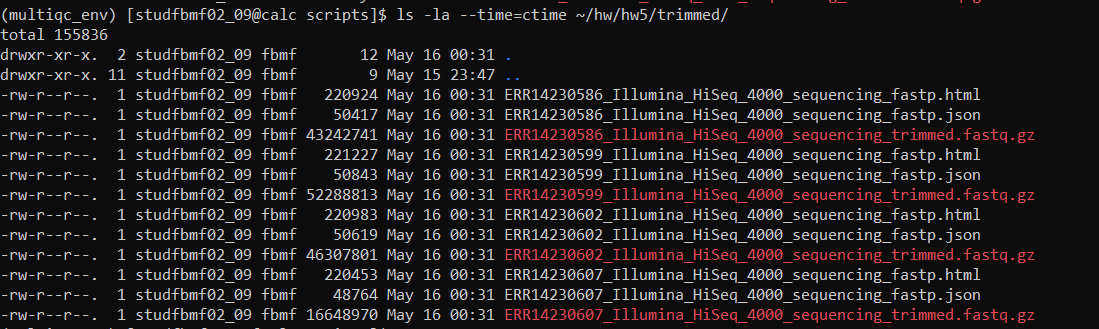

---
## Часть 3 — Контроль качества после тримминга

### 3.1 SLURM-скрипты: FastQC и MultiQC после тримминга

### 3.2 Сравнение метрик до и после тримминга

#### Общая статистика

| Образец | % Dups | % GC | Ср. длина (bp) | M Seqs |
|---|---|---|---|---|
| ERR14230586 (до) | 22.9% | 46% | 45 | 1.8 |
| ERR14230586 (после) | **16.7%** ↓ | 46% = | **48** ↑ | 1.5 ↓ |
| ERR14230599 (до) | 18.8% | 47% | 47 | 2.0 |
| ERR14230599 (после) | **14.2%** ↓ | 46% ≈ | **50** ↑ | 1.7 ↓ |
| ERR14230602 (до) | 15.3% | 46% | 46 | 1.8 |
| ERR14230602 (после) | **10.9%** ↓ | 45% ≈ | **48** ↑ | 1.5 ↓ |
| ERR14230607 (до) | 64.1% | 49% | 41 | 1.1 |
| ERR14230607 (после) | **59.5%** ↓ | 48% ≈ | **44** ↑ | 0.7 ↓ |

#### Статусы FastQC-модулей: до → после

| Модуль | До | После | Изменение |
|---|---|---|---|
| Basic statistics | 4× Pass | 4× Pass | = |
| Per-base sequence quality | 4× Pass | 4× Pass | = |
| Per-tile sequence quality | 3× Pass, 1× Warn | 3× Pass, **1× Fail** | ↓ ERR14230607 |
| Per-sequence quality scores | 4× Pass | 4× Pass | = |
| Per-base sequence content | 3× Fail, 1× Warn | 3× Fail, 1× Warn | = |
| Per-sequence GC content | 2× Fail, 2× Warn | **1× Fail**, 3× Warn | ↑ незначительно |
| Per-base N content | 4× Pass | 4× Pass | = |
| Sequence length distribution | 4× Warn | 4× Warn | = |
| Sequence duplication levels | 3× Pass, 1× Fail | 3× Pass, 1× Fail | = |
| Overrepresented sequences | 3× Warn, 1× Fail | 3× Warn, 1× Fail | = |
| Adapter content | 4× Pass | 4× Pass | = |

### 3.3 Улучшившиеся аспекты и их объяснение

- % Дупликатов снизился у всех образцов**

fastp удалил короткие и низкокачественные риды, которые с большей вероятностью являются артефактными копиями. После тримминга случайные дубли за счёт плохих ридов исчезают из выборки, поэтому расчётный % дупликатов снижается.

-  Средняя длина рида выросла на 2–3 bp**

Странный результат на первый взгляд: тримминг обрезает риды, но средняя длина выросла. Объяснение: `--length_required 36` удалил все короткие риды, обрезанные до < 36 bp. Оставшиеся риды — те, которые изначально были достаточно длинными и хорошего качества. Их средняя длина выше, чем средняя по всей исходной выборке.

-  GC content: один образец улучшился с Fail → Warn**

Удаление некачественных ридов незначительно выровняло GC-распределение одного образца (ERR14230599).

### 3.4 Что не изменилось и почему

**Per-base sequence content — по-прежнему Fail у 3 образцов**

Смещение нуклеотидного состава в начале ридов — это артефакт random hexamer priming в RNA-seq библиотеках, а не техническая проблема качества. Случайные гексамерные праймеры создают предпочтительные контексты на первых 10–13 позициях рида. Этот эффект нельзя устранить тримминговыми инструментами - его нужно либо принимать как особенность RNA-seq данных, либо применять специализированные методы коррекции (например, `--trim_poly_g` или корректировку смещения праймеров при квантификации).

**Overrepresented sequences — без изменений**

Присутствие гиперабундантных транскриптов (вероятно, рРНК) отражает биологический состав образца, а не технический артефакт. Для их устранения необходимы этапы деплеции рРНК или отдельная фильтрация по известным контаминантам.

**ERR14230607: Per-tile quality ухудшился с Warn → Fail**

Плохое качество отдельных тайлов flowcell — аппаратный артефакт секвенирования. Тримминг обрабатывает последовательности, но не устраняет систематическое ухудшение качества, связанное с конкретной физической ячейкой проточной кюветы. Вероятно, при тримминге были удалены «средние» риды, и оставшиеся данные с плохих тайлов стали более заметны статистически.

### 3.5 Визуализация изменений метрик

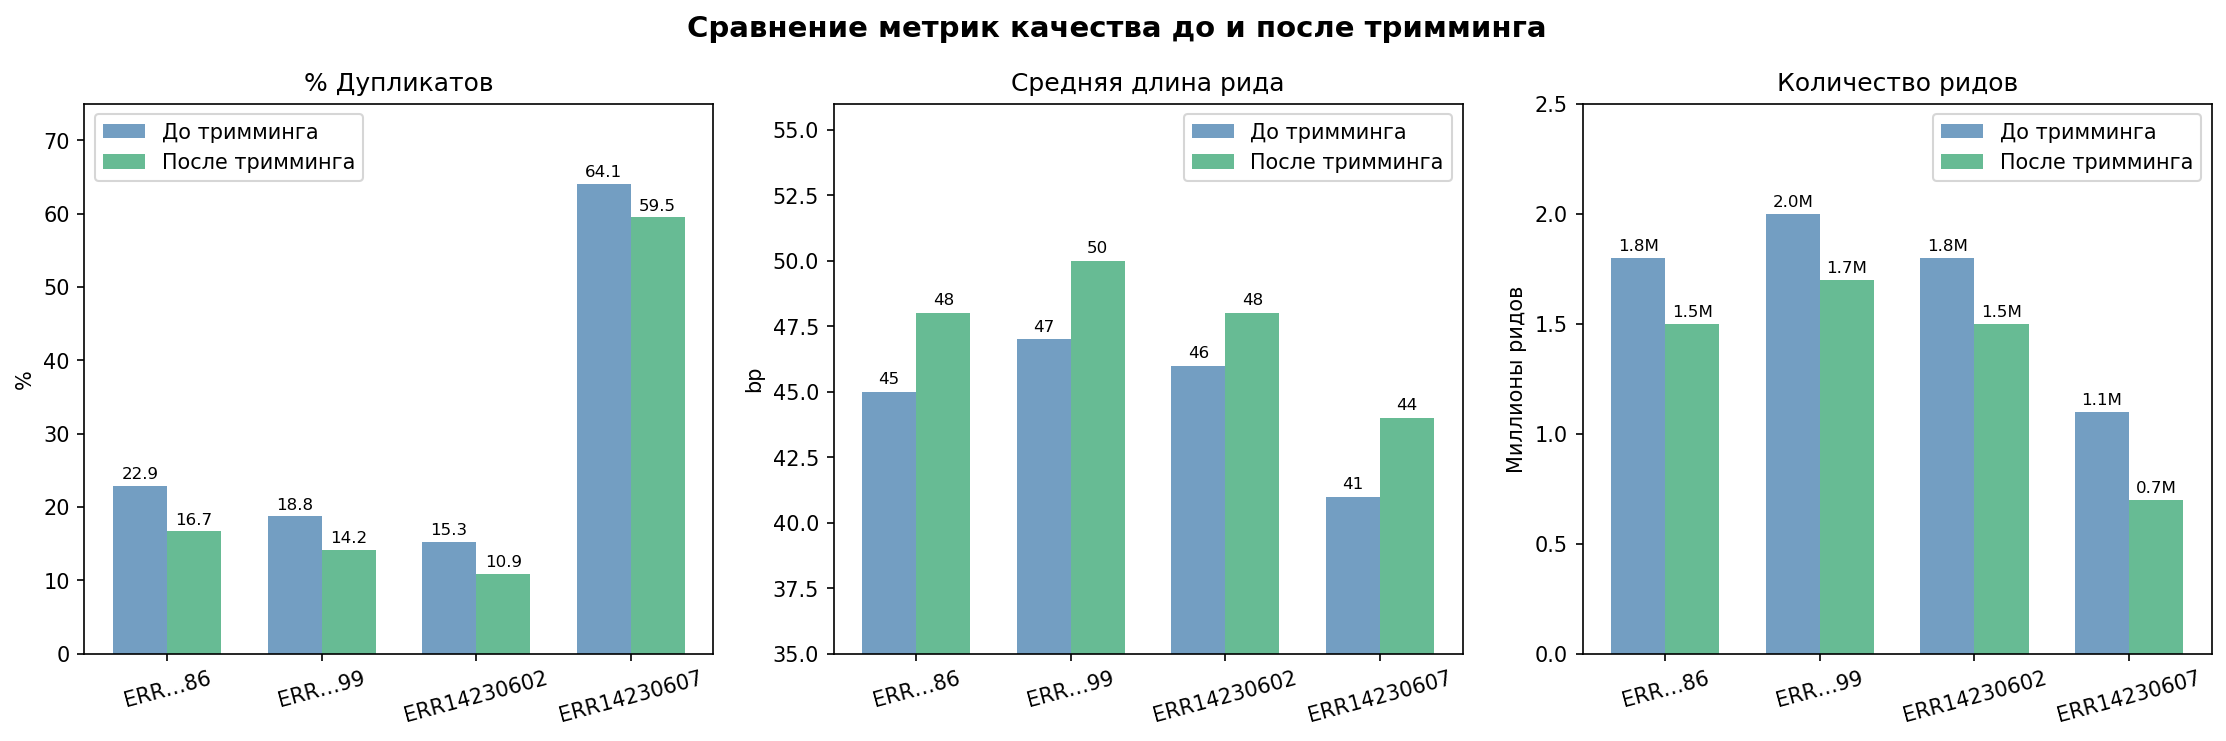

---
## Выводы

### 1. Качество исходных данных

Данные из проекта PRJEB84057 (RNA-seq, Illumina HiSeq 4000) имеют хорошее базовое качество — `Per-base sequence quality` и `Per-sequence quality scores` показали `Pass` у всех образцов. Обнаруженные проблемы носят преимущественно биологический, а не технический характер.

### 2. Результаты тримминга

fastp успешно выполнил очистку данных:
- % дупликатов снизился у всех образцов (−4.4% до −6.2%) — улучшение качества выборки
- Средняя длина рида выросла на 2–3 bp — удалены короткие низкокачественные риды
- Адаптеры не были обнаружены ни до, ни после тримминга
- Потеря ридов составила ≈15–36% в зависимости от образца (что ожидаемо при фильтрации по длине ≥36 bp)

### 3. Метрики без видимого улучшения

| Метрика | Причина отсутствия изменений |
|---|---|
| Per-base sequence content | Биологический артефакт random hexamer priming (RNA-seq) |
| GC content | Отражает реальное биологическое GC-распределение транскриптома |
| Overrepresented sequences | Высокоабундантные транскрипты (вероятно рРНК) |
| Per-tile quality (ERR14230607) | Аппаратный артефакт flowcell |

### 4. Проблемный образец ERR14230607

Образец ERR14230607 демонстрирует нетипично высокий уровень дупликатов (64.1%), аппаратный дефект тайлов и наибольшие потери при тримминге (36% ридов). При дальнейшем анализе этот образец следует рассматривать с осторожностью.

### 5. Общий итог

 Итого, данные успешно прошли контроль качества и тримминг. Отсутствие драматических изменений в некоторых FastQC-метриках после тримминга ожидаемо для данного типа данных
